In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
from utils import *
from scipy.sparse.linalg import expm
from scipy.sparse import kron
import matplotlib.pyplot as plt

In [2]:
def get_xy_minus_yx(theta):
    circuit = QuantumCircuit(2)
    # YX / 2
    circuit.rz(-np.pi / 2, 1)
    circuit.rxx(theta / 2, 0, 1)
    circuit.rz(np.pi / 2, 1)
    # - XY / 2
    circuit.rz(-np.pi / 2, 0)
    circuit.rxx(-theta / 2, 0, 1)
    circuit.rz(np.pi / 2, 0)
    
    return circuit

def is_power_of_two(n):
    return (n != 0) and (n & (n-1) == 0)

def one_hot_fft_circuit(N):
    # Note: Input is permuted, output is ordered normally
    # Exponent is -2 * pi * i (consistent with numpy)
    assert is_power_of_two(N), "only implemented for power of 2"

    circuit = QuantumCircuit(N)

    if N == 1:
        return circuit
    else:
        upper_half = list(np.arange(0, N // 2))
        lower_half = list(np.arange(N // 2, N))

        half_size_qft = one_hot_fft_circuit(N // 2)
        # Compute QFT on even and odd indices
        circuit.append(half_size_qft, qargs=upper_half)
        circuit.append(half_size_qft, qargs=lower_half)

        # Combine the results
        for k in range(N // 2):
            circuit.z(lower_half[k])
            circuit.p((-2 * np.pi * k / N), lower_half[k])
            # circuit.rz(2 * (2 * np.pi * k / N + np.pi / 2), k)
        for k in range(N // 2):
            circuit.append(get_xy_minus_yx(theta=np.pi/2), qargs=[upper_half[k], lower_half[k]])

        return circuit

def permute_codewords(N, codewords):
    assert is_power_of_two(N)
    if N == 2:
        return codewords
    else:
        codewords_permuted_even = permute_codewords(N // 2, [codewords[i] for i in np.arange(0, N, 2)])
        codewords_permuted_odd = permute_codewords(N // 2, [codewords[i] for i in np.arange(1, N, 2)])
        return codewords_permuted_even + codewords_permuted_odd

In [3]:
theta = np.pi/2

xy_minus_yx = expm(-1j * (theta / 2) * ((tensor([PAULI_Y, PAULI_X]) - tensor([PAULI_X, PAULI_Y])) / 2).tocsc())
print(xy_minus_yx.toarray())

circ_xy_minus_yx = Operator(get_xy_minus_yx(theta)).to_matrix()

np.abs(np.trace(circ_xy_minus_yx @ np.conj(xy_minus_yx.T))) / 4

[[ 1.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.70710678+0.j -0.70710678+0.j  0.        +0.j]
 [ 0.        +0.j  0.70710678+0.j  0.70710678+0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j  1.        +0.j]]


0.9999999999999998

In [4]:
N = 4
dimension = 1
encoding = "one-hot"
codewords = get_codewords(N, dimension, encoding)
amplitudes = np.random.rand(N) + np.random.rand(N) * 1j
amplitudes /= np.linalg.norm(amplitudes)
circ = state_prep_one_hot(N, dimension, amplitudes)
np.abs(Operator(circ).to_matrix()[codewords,0] @ np.conj(amplitudes))

In [5]:
N = 8
codewords_permuted = permute_codewords(N, list(range(N)))
print(codewords_permuted)

[0, 4, 2, 6, 1, 5, 3, 7]


In [1]:
4 * 16

64

In [16]:
N = 8
dimension = 1
encoding = "one-hot"
codewords = get_codewords(N, dimension, encoding)
codewords_permuted = permute_codewords(N, codewords)

qft = one_hot_fft_circuit(N)
# 4 * 16 * 2 = 128 two-qubit gates to simulate the Hamiltonian
# O(N) gates for state preparation
# 64 AAMS gates for N=16

qft_circ = Operator(qft).to_matrix()
qft_circ_subspace = qft_circ[codewords][:,codewords_permuted]

[1, 2, 4, 8, 16, 32, 64, 128]
[1, 16, 4, 64, 2, 32, 8, 128]


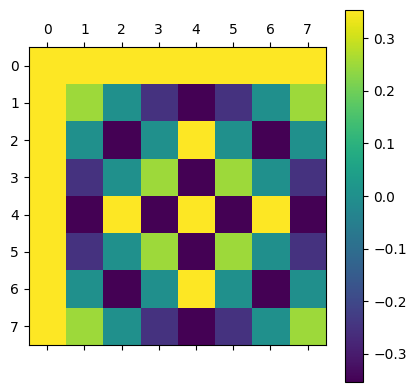

In [8]:
plt.matshow(qft_circ_subspace.real)
plt.colorbar()
plt.show()

Fidelity: 0.9999999999999993


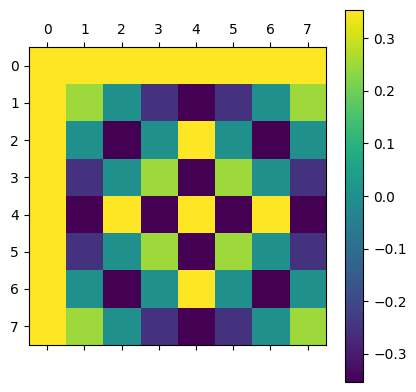

In [9]:
FFT = np.fft.fft(np.eye(N), norm="ortho")
print("Fidelity:", np.abs(np.trace(np.fft.ifft(qft_circ_subspace, norm="ortho"))) / N)
plt.matshow(FFT.real)
plt.colorbar()
plt.show()
